In [1]:
import numpy as np
import pandas as pd
from faiss import IndexFlatIP, IndexHNSWFlat
from tqdm.notebook import tqdm
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_parquet('embeddings_policies_Qwen3-4B_2026-03-05.parquet')

In [3]:
embs = np.stack(df.embedding.values).astype('float32')

In [6]:
dim = embs.shape[1]
neighbours = 128  # higher is more accurate but more resource intensive
index = IndexHNSWFlat(dim, neighbours)

In [7]:
index.add(embs)

# Star algorithm
Order-dependent, produces way too many clusters

In [13]:
threshold = 0.995
row_offset = 0
batch_size = 100
representative = np.arange(len(df), dtype=np.int64)  # start: everyone is their own rep
len(representative), len(set(representative))

(1466027, 1466027)

In [14]:
for start in tqdm(range(0, len(embs), batch_size)):
    batch = embs[start:start+batch_size]
    lims, distances, neighbors = index.range_search(batch, threshold)
    for local_i in range(len(batch)):
        global_i = row_offset + local_i
        # Skip if already marked as a duplicate
        if representative[global_i] != global_i:
            continue
        batch_neighbors = neighbors[lims[local_i]:lims[local_i + 1]]
        for j in batch_neighbors:
            if j > global_i and representative[j] == j:  # only mark later rows as duplicates of earlier ones
                representative[j] = global_i

    row_offset += len(batch)

  0%|          | 0/14661 [00:00<?, ?it/s]

In [15]:
len(representative), len(set(representative))

(1466027, 32709)

In [16]:
df['cluster_idx'] = representative

In [88]:
silhouette_score(embs, df['cluster_idx'].values, metric='cosine', sample_size=50_000) # eps = 0.98

-0.20651660859584808

In [17]:
df['cluster_idx'].value_counts().head(10)

cluster_idx
230     1235
106     1127
305     1105
15      1093
642     1038
2308    1036
2136     998
268      974
306      957
1005     951
Name: count, dtype: int64

In [18]:
df[df['cluster_idx'] == 106].policy_text.values.tolist()

['Development of economically sustainable models and optimal size and enterprise mix to provide employment and reasonable return',
 'Labour for organic farms - availability, training, feasibility of an organic job centre or labour pool',
 'Reconceptualising the shared images used in discussions and models of trade, regions and development',
 'Offering ICDP activities to local communities as compensation for lost revenues',
 'Subsidising local economy components to support community livelihoods',
 'Enhanced management and promotion of the environmental service to improve economic impacts',
 'Small-scale enterprise development',
 'Production systems based on local resources',
 'Employment creation in agriculture for local labor',
 'Incorporate key economic processes into the model, such as price fluctuations for horticultural crops and the articulation between on-farm and off-farm employment.',
 'Economic model of development',
 'Mobilisation of resources through clear articulation of ni

# K-means -> really bad
Silhouette score is misleading, clusters seem considerably worse than Leiden on manual inspection.

In [72]:
from sklearn.cluster import KMeans, MiniBatchKMeans

In [73]:
cluster = MiniBatchKMeans(n_clusters=2000, verbose=1)

In [79]:
shuf = embs.copy()
np.random.shuffle(shuf)

In [81]:
cluster.fit(shuf)

Init 1/1 with method k-means++
Inertia for init 1/1: 1818.6380615234375
[MiniBatchKMeans] Reassigning 512 cluster centers.
Minibatch step 1/143166: mean batch inertia: 0.5897365808486938
[MiniBatchKMeans] Reassigning 512 cluster centers.
Minibatch step 2/143166: mean batch inertia: 0.5260093212127686, ewa inertia: 0.5260093212127686
[MiniBatchKMeans] Reassigning 512 cluster centers.
Minibatch step 3/143166: mean batch inertia: 0.48111966252326965, ewa inertia: 0.5259466116185479
[MiniBatchKMeans] Reassigning 512 cluster centers.
Minibatch step 4/143166: mean batch inertia: 0.4626051187515259, ewa inertia: 0.5258581253294787
[MiniBatchKMeans] Reassigning 512 cluster centers.
Minibatch step 5/143166: mean batch inertia: 0.4600696861743927, ewa inertia: 0.5257662207250717
[MiniBatchKMeans] Reassigning 512 cluster centers.
Minibatch step 6/143166: mean batch inertia: 0.4482247531414032, ewa inertia: 0.5256578974695736
[MiniBatchKMeans] Reassigning 512 cluster centers.
Minibatch step 7/1431

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.",2000
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:'k-means++' : selects initial cluster centroids using sampling based onan empirical probability distribution of the points' contribution to theoverall inertia. This technique speeds up convergence. The algorithmimplemented is ""greedy k-means++"". It differs from the vanilla k-means++by making several trials at each sampling step and choosing the best centroidamong them.'random': choose `n_clusters` observations (rows) at random from datafor the initial centroids.If an array is passed, it should be of shape (n_clusters, n_features)and gives the initial centers.If a callable is passed, it should take arguments X, n_clusters and arandom state and return an initialization.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=100Maximum number of iterations over the complete dataset beforestopping independently of any early stopping criterion heuristics.",100
,"batch_size batch_size: int, default=1024Size of the mini batches.For faster computations, you can set `batch_size > 256 * number_of_cores`to enable :ref:`parallelism `on all cores... versionchanged:: 1.0 `batch_size` default changed from 100 to 1024.",1024
,"verbose verbose: int, default=0Verbosity mode.",1
,"compute_labels compute_labels: bool, default=TrueCompute label assignment and inertia for the complete datasetonce the minibatch optimization has converged in fit.",True
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization andrandom reassignment. Use an int to make the randomness deterministic.See :term:`Glossary `.",None
,"tol tol: float, default=0.0Control early stopping based on the relative center changes asmeasured by a smoothed, variance-normalized of the mean centersquared position changes. This early stopping heuristics iscloser to the one used for the batch variant of the algorithmsbut induces a slight computational and memory overhead over theinertia heuristic.To disable convergence detection based on normalized centerchange, set tol to 0.0 (default).",0.0
,"max_no_improvement max_no_improvement: int, default=10Control early stopping based on the consecutive number of minibatches that does not yield an improvement on the smoothed inertia.To disable convergence detection based on inertia, setmax_no_improvement to None.",10
,"init_size init_size: int, default=NoneNumber of samples to randomly sample for speeding up theinitialization (sometimes at the expense of accuracy): theonly algorithm is initialized by running a batch KMeans on arandom subset of the data. This needs to be larger than n_clusters.If `None`, the heuristic is `init_size = 3 * batch_size` if`3 * batch_size < n_clusters`, else `init_size = 3 * n_clusters`.",None
,"n_init n_init: 'auto' or int, default=""auto""Number of random initializations that are tried.In contrast to KMeans, the algorithm is only run once, using the best ofthe `n_init` initializations as measured by inertia. Several runs arerecommended for sparse high-dimensional problems (see:ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:3 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'` in version.",'auto'


In [82]:
preds = cluster.predict(embs)
df['cluster_idx'] = preds

In [83]:
silhouette_score(embs, df['cluster_idx'].values, metric='cosine', sample_size=50_000)

-0.04934841766953468

In [61]:
df['cluster_idx'].value_counts().head(20)

cluster_idx
236     3607
1349    3495
804     3209
774     3149
350     3115
245     3040
448     3039
308     2859
47      2832
1261    2817
1635    2748
54      2683
1708    2665
153     2645
391     2644
1663    2548
629     2543
42      2539
203     2536
373     2487
Name: count, dtype: int64

In [64]:
df[df['cluster_idx'] == 373].policy_text.values.tolist()

['Web-based support group for gynaecologic cancer patients with psychosexual distress',
 'Continuing with the strategy of testing chemopreventive agents',
 'Conducting extensive studies on chemopreventive agents to gain knowledge on their safety, efficacy, and mechanism of action',
 'Nutritional counseling for cancer patients to improve various aspects of quality of life',
 'Dietary supplementation for cancer patients to improve quality of life',
 'Inclusion of therapeutic and nutrition guidelines based on the relationship between nutritional status and quality of life in the treatment protocol of cancer patients',
 'Consideration of improved quality of life as an important outcome for cancer patients after any nutritional intervention',
 'Nutritional counseling for cancer patients',
 'Supplemental feeding for cancer patients',
 'Pharmacological support for cancer patients',
 'Research on the pathophysiology of cancer induced cachexia',
 'Customized stress management programs aimed at 

# Community detection

In [8]:
import networkit as nk

In [9]:
nk_g = nk.Graph(len(embs), weighted=True, directed=False)

In [10]:
threshold = 0.9
batch_size = 100

for start in tqdm(range(0, len(embs), batch_size)):
    end = min(start + batch_size, len(embs))
    batch = embs[start:end]
    
    lims, distances, neighbors = index.range_search(batch, threshold)
    
    for local_i in range(len(batch)):
        global_i = start + local_i
        start_idx = lims[local_i]
        end_idx = lims[local_i + 1]
        
        node_neighbors = neighbors[start_idx:end_idx]
        node_distances = distances[start_idx:end_idx]
        
        for neighbor_j, dist in zip(node_neighbors, node_distances):
            # Only add edges where i < j to avoid duplicates and self-loops
            if global_i < neighbor_j:
                weight = (float(dist) - threshold) / (1 - threshold)  # rescale for higher contrast
                weight = max(0.0001, weight) # ensure positive weights
                nk_g.addEdge(global_i, int(neighbor_j), w=weight)

  0%|          | 0/14661 [00:00<?, ?it/s]

In [10]:
nk.writeGraph(nk_g,"./policy_graph.nkbg003", nk.Format.NetworkitBinary, chunks=16, NetworkitBinaryWeights=4)

In [12]:
leiden = nk.community.ParallelLeiden(nk_g, iterations=10, gamma=100)
leiden.run()

In [13]:
df['cluster_id'] = leiden.getPartition().getVector()
df.cluster_id.nunique()

2419

In [ ]:
#nk.community.Modularity().getQuality(leiden.getPartition(), nk_g) this kills the kernel

In [12]:
df

,openalex_id,chunk_idx,domain,policy_type,actor,policy_text,embedding
0,W1000416519,0,URBAN,ECONOMIC,NATIONAL,Buyouts of property and structures as part of ...,"[-0.000351, 0.04614, 0.02902, 0.01041, -0.0021..."
1,W1000416519,0,URBAN,ECONOMIC,REGIONAL,Prioritization of parcels for buyouts to reduc...,"[-0.0004473, 0.03687, 0.008736, 0.01563, -0.00..."
2,W1000416519,0,NATURE,SPATIAL,NATIONAL,"Restoration of natural resources, including we...","[-0.0002345, -0.00078, -0.02588, -0.003849, -0..."
3,W1000416519,0,NATURE,SPATIAL,REGIONAL,Restoration of salmonid habitat in Sonoma Coun...,"[-0.0002744, 0.05298, -0.01653, 0.00801, -0.00..."
4,W1000416519,1,NATURE,ECONOMIC,NATIONAL,National Oceanic and Atmospheric Administratio...,"[-0.0001951, 0.02393, -0.00818, 0.06274, -0.00..."
...,...,...,...,...,...,...,...
1466022,W991832166,5,SOCIAL,REGULATORY,NATIONAL,Minority lists that fail to win preferential m...,"[-0.000576, 0.01172, -0.01033, 0.008766, -0.00..."
1466023,W991832166,5,SOCIAL,REGULATORY,NATIONAL,Minority MPs and spokespersons can found perma...,"[-0.0006123, 0.01182, -0.01665, 0.0316, -0.001..."
1466024,W991832166,5,SOCIAL,REGULATORY,NATIONAL,The new constitution places lesser importance ...,"[-0.0005507, 0.06198, 0.0279, 0.0116, -0.00221..."
1466025,W991832166,5,SOCIAL,REGULATORY,NATIONAL,The general line of internal minority policy h...,"[-0.0004122, 0.06134, 0.0211, 0.03714, -0.0014..."


In [48]:
# eps = 0.9
# weighted with rescaling
# gamma = 25
silhouette_score(embs, df['cluster_id'].values, metric='cosine', sample_size=50_000)

0.032295115292072296

In [37]:
# eps = 0.9
# weighted with rescaling
# gamma = 50
silhouette_score(embs, df['cluster_id'].values, metric='cosine', sample_size=50_000)

-0.0214280616492033

In [24]:
# eps = 0.9
# weighted with rescaling
# gamma = 200
silhouette_score(embs, df['cluster_id'].values, metric='cosine', sample_size=50_000)

-0.11926589161157608

In [11]:
# eps = 0.9
# weighted with rescaling
silhouette_score(embs, df['cluster_id'].values, metric='cosine', sample_size=50_000)

-0.07033403217792511

In [26]:
# eps = 0.92
# weighted
silhouette_score(embs, df['cluster_id'].values, metric='cosine', sample_size=50_000)

-0.04530631750822067

In [110]:
# eps = 0.99
# non-weighted
silhouette_score(embs, df['cluster_id'].values, metric='cosine', sample_size=50_000)

-0.04347739368677139

In [110]:
# eps = 0.95
# non-weighted
silhouette_score(embs, df['cluster_id'].values, metric='cosine', sample_size=50_000)

-0.04347739368677139

In [105]:
# eps = 0.95
# weighted
silhouette_score(embs, df['cluster_id'].values, metric='cosine', sample_size=50_000)

-0.04581524059176445

In [99]:
# eps = 0.98
# weighted
silhouette_score(embs, df['cluster_id'].values, metric='cosine', sample_size=50_000)

-0.050624534487724304

In [64]:
# eps = 0.98
# non weighted
silhouette_score(embs, df['cluster_id'].values, metric='cosine', sample_size=50_000)

-0.03414539620280266

In [60]:
df.policy_text.str.len().sum() / 3 / len(df)

np.float64(37.97026794185919)

In [14]:
scores = {}
for gamma in [50, 75, 100, 125, 150, 175, 200]:
    leiden = nk.community.ParallelLeiden(nk_g, iterations=10, gamma=gamma)
    leiden.run()

    col = f'cluster_id_gamma_{gamma}'
    df[col] = leiden.getPartition().getVector()

    sc = silhouette_score(embs, df[col].values, metric='cosine', sample_size=100_000)
    scores[gamma] = sc
    print(f"gamma={gamma} -> {df[col].nunique()} clusters, silhouette score = {sc}")

gamma=50 -> 1519 clusters, silhouette score = -0.003440097440034151
gamma=75 -> 1933 clusters, silhouette score = -0.04527663439512253
gamma=100 -> 2434 clusters, silhouette score = -0.0734727531671524
gamma=125 -> 3069 clusters, silhouette score = -0.09389764815568924
gamma=150 -> 3799 clusters, silhouette score = -0.10682973265647888
gamma=175 -> 4681 clusters, silhouette score = -0.1266641765832901
gamma=200 -> 5671 clusters, silhouette score = -0.14334280788898468


In [18]:
import sys

In [20]:
sys.getsizeof(df) / 1e9

0.548254017

In [21]:
cop = df.copy()

In [24]:
cop = cop.drop(columns=['embedding'])

In [26]:
sys.getsizeof(cop) / 1e9

0.372330777

In [27]:
cop.to_parquet('clustered_policies_varying_gamma_2026-03-09.parquet')

In [28]:
pd.read_parquet('clustered_policies_varying_gamma_2026-03-09.parquet')

,openalex_id,chunk_idx,domain,policy_type,actor,policy_text,cluster_id_gamma_50,cluster_id_gamma_75,cluster_id_gamma_100,cluster_id_gamma_125,cluster_id_gamma_150,cluster_id_gamma_175,cluster_id_gamma_200
0,W1000416519,0,URBAN,ECONOMIC,NATIONAL,Buyouts of property and structures as part of ...,0,0,0,0,0,0,0
1,W1000416519,0,URBAN,ECONOMIC,REGIONAL,Prioritization of parcels for buyouts to reduc...,1,1,1,1,0,0,1
2,W1000416519,0,NATURE,SPATIAL,NATIONAL,"Restoration of natural resources, including we...",2,2,2,2,1,1,2
3,W1000416519,0,NATURE,SPATIAL,REGIONAL,Restoration of salmonid habitat in Sonoma Coun...,3,3,3,3,2,2,3
4,W1000416519,1,NATURE,ECONOMIC,NATIONAL,National Oceanic and Atmospheric Administratio...,4,4,4,4,3,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1466022,W991832166,5,SOCIAL,REGULATORY,NATIONAL,Minority lists that fail to win preferential m...,549,689,825,647,684,734,753
1466023,W991832166,5,SOCIAL,REGULATORY,NATIONAL,Minority MPs and spokespersons can found perma...,549,505,825,647,684,734,753
1466024,W991832166,5,SOCIAL,REGULATORY,NATIONAL,The new constitution places lesser importance ...,452,505,657,647,684,734,753
1466025,W991832166,5,SOCIAL,REGULATORY,NATIONAL,The general line of internal minority policy h...,452,505,990,647,684,734,753


In [49]:
df['cluster_id'].value_counts().head(20)

cluster_id
62     12012
217    11480
78     10916
36     10875
25     10061
323    10024
93      9969
161     9818
40      9687
31      9502
133     9207
153     9086
265     9034
326     9031
253     9004
59      8937
113     8880
71      8622
276     8616
124     8501
Name: count, dtype: int64

In [52]:
df[df['cluster_id'] == 78].policy_text.values.tolist()

['Commitment and involvement of all project participants in waste identification and elimination',
 'Improvement of port trash collection programs',
 'Specialized removal and disposal measures for hazardous materials',
 'Diverting the bypass circuit to clear bag waste for disposal in waste-to-energy facilities to reduce environmental impact and annual cost savings',
 'Implementation of separating technologies for aluminium in the transportation, building and construction, and machinery and equipment sectors to avoid loss of aluminium scrap.',
 'Improvement of the waste management system in the Emilia-Romagna region to achieve a net closure of flows and reduce carbon emissions.',
 'European waste hierarchy',
 'Exception to the ban on waste disposal for dredging spoils containing substances listed in Annex I of the London Convention 1972 and Annex I of the Barcelona Convention 1976, provided they meet certain characteristics.',
 'Parties contractantes must ensure that no waste or other m

<Axes: xlabel='cluster_id'>

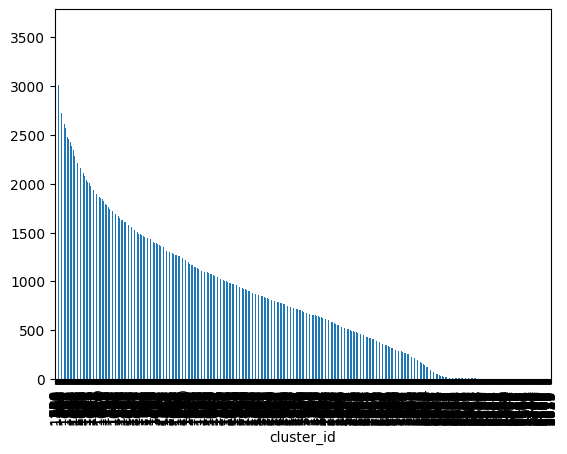

In [38]:
df['cluster_id'].value_counts().plot(kind='bar')

In [44]:
counts = df['cluster_id'].value_counts()
lone_cluster_ids = counts[counts == 1].index
df['cluster_id'].isin(lone_cluster_ids).sum()

np.int64(174)

In [45]:
df[df['cluster_id'].isin(lone_cluster_ids)].policy_text.values.tolist()

['Széchenyi Plan: A national development plan that included significant investments in spa and tourism infrastructure, aiming to boost the economy and improve quality of life through increased tourism and enhanced services.',
 'Finnish Test Year [12]',
 'Athens’ TMY (Greece) [15]',
 'Incentivising utility companies by their regulator to make decisions that consider impacts such as road user delays, fuel consumption, impact of reinstatement, and carbon emissions.',
 'Guidance for the Safe Transportation of Medical Oxygen for Personal Use on Buses and Trains, which recommends secure storage and limiting one canister per patient in the passenger compartment',
 'Briefings to high-level officials, including the President of France, Ministers of Agriculture in Brazil, Germany, and Uruguay, and U.S. Senate and House of Representatives committees.',
 'Trying to rollover the parameters of the 79/416 contract, which would build on the prior elimination of 100 positions and sought to cut 10 perce